In [ ]:
from five_bar.five_bar import five_bar
import mujoco as mj
import mediapy as media
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

robot = five_bar(SERIAL_PORT="COM16", max_speed=300)

target1=135
target2=-135

robot.set_control_mode("position",target1,target2)

robot.start()



Initializing Robot...

Connecting to CAN bus COM16...
Successfully connected to CAN bus COM16!

Robot Initialized. 
Defaulting to control mode: 'torque'
Start threads to begin using the robot

Control Mode set to 'position'. Setting targets to [135, -135]

Starting Read/write threads...
Read/write threads started!



Aborting: Motors reached maximum allowed speed, setting control mode to torque and setting targets to [0,0]
Aborting: Motors reached maximum allowed speed, setting control mode to torque and setting targets to [0,0]
Aborting: Motors reached maximum allowed speed, setting control mode to torque and setting targets to [0,0]
Aborting: Motors reached maximum allowed speed, setting control mode to torque and setting targets to [0,0]
Aborting: Motors reached maximum allowed speed, setting control mode to torque and setting targets to [0,0]
Aborting: Motors reached maximum allowed speed, setting control mode to torque and setting targets to [0,0]
Aborting: Motors reached maximum allowed speed, setting control mode to torque and setting targets to [0,0]
Aborting: Motors reached maximum allowed speed, setting control mode to torque and setting targets to [0,0]
Aborting: Motors reached maximum allowed speed, setting control mode to torque and setting targets to [0,0]
Aborting: Motors reached max

In [2]:
theta1_pick=177.97408142381062
theta2_pick=-108.94326081883368

theta1_place=108.94326081883368
theta2_place=-177.97408142381062

In [113]:
robot.reactivate()

In [135]:
robot.set_control_mode("position",theta1_pick,theta2_pick)

Control Mode set to 'position'. Setting targets to [177.97408142381062, -108.94326081883368]



In [107]:
def quintic_trajectory(theta_i, theta_f, speed_i, speed_f, acceleration_i, acceleration_f, T):
    """
    Returns the coefficients [a0, a1, a2, a3, a4, a5] of the quintic polynomial:
    θ(t) = a0 + a1*t + a2*t^2 + a3*t^3 + a4*t^4 + a5*t^5
    that interpolates position, velocity, and acceleration at t=0 and t=T.
    """
    a0 = theta_i
    a1 = speed_i
    a2 = acceleration_i / 2

    # Setup linear system for [a3, a4, a5]
    A = np.array([
        [T**3,    T**4,     T**5],
        [3*T**2,  4*T**3,   5*T**4],
        [6*T,     12*T**2,  20*T**3]
    ])
    B = np.array([
        theta_f - (a0 + a1*T + a2*T**2),
        speed_f - (a1 + 2*a2*T),
        acceleration_f - (2*a2)
    ])

    a3, a4, a5 = np.linalg.solve(A, B)

    return [a0, a1, a2, a3, a4, a5]

def evaluate_quintic(coeffs, t, T):
    """
    Evaluates θ(t), θ̇(t), and θ̈(t) for a quintic polynomial:
    θ(t) = a0 + a1*t + a2*t^2 + a3*t^3 + a4*t^4 + a5*t^5

    Args:
        coeffs (list): Coefficients [a0, a1, a2, a3, a4, a5] of the quintic polynomial.
        t (float): Time at which to evaluate.
        T (float): Total duration, used to clamp t between 0 and T.

    Returns:
        list: [θ(t), θ̇(t), θ̈(t)]
    """
    a0, a1, a2, a3, a4, a5 = coeffs
    
    t = max(0, min(t, T))  # Clamp t to [0, T]

    theta = a0 + a1*t + a2*t**2 + a3*t**3 + a4*t**4 + a5*t**5
    theta_dot = a1 + 2*a2*t + 3*a3*t**2 + 4*a4*t**3 + 5*a5*t**4
    theta_dotdot = 2*a2 + 6*a3*t + 12*a4*t**2 + 20*a5*t**3

    return [theta, theta_dot, theta_dotdot]


In [109]:
trajectory_time=0.3

#Coeffs to go
coeffs_theta1_go = quintic_trajectory(theta_i=theta1_pick, theta_f=theta1_place, speed_i=0, speed_f=0,acceleration_i=0, acceleration_f=0, T=trajectory_time)
coeffs_theta2_go = quintic_trajectory(theta_i=theta2_pick, theta_f=theta2_place, speed_i=0, speed_f=0,acceleration_i=0, acceleration_f=0,T=trajectory_time)

#Coeffs to back
coeffs_theta1_back = quintic_trajectory(theta_i=theta1_place, theta_f=theta1_pick, speed_i=0, speed_f=0,acceleration_i=0, acceleration_f=0, T=trajectory_time)
coeffs_theta2_back = quintic_trajectory(theta_i=theta2_place, theta_f=theta2_pick, speed_i=0, speed_f=0, acceleration_i=0, acceleration_f=0,T=trajectory_time)

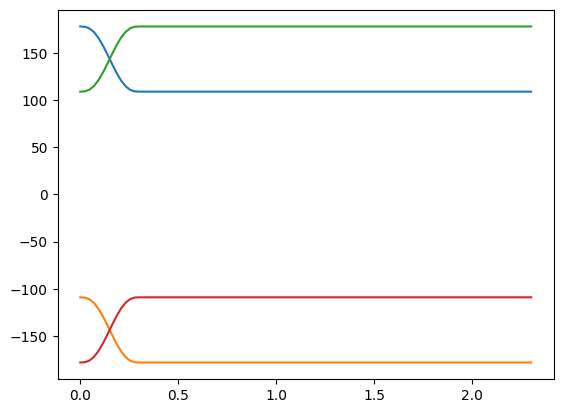

In [155]:
times=np.linspace(0,trajectory_time+2,100)
plt.plot(times,[evaluate_quintic(coeffs_theta1_go,time,trajectory_time)[0] for time in times])
plt.plot(times,[evaluate_quintic(coeffs_theta2_go,time,trajectory_time)[0] for time in times])
plt.plot(times,[evaluate_quintic(coeffs_theta1_back,time,trajectory_time)[0] for time in times])
plt.plot(times,[evaluate_quintic(coeffs_theta2_back,time,trajectory_time)[0] for time in times])

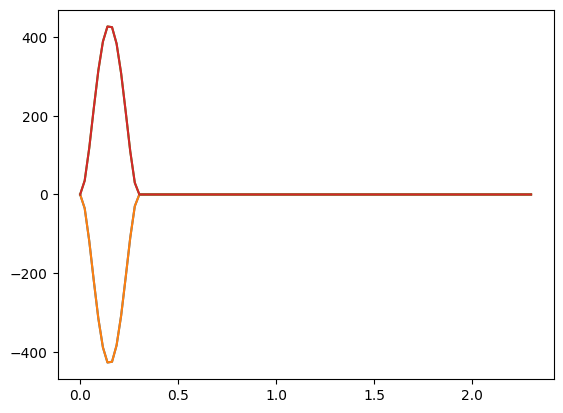

In [156]:
plt.plot(times,[evaluate_quintic(coeffs_theta1_go,time,trajectory_time)[1] for time in times])
plt.plot(times,[evaluate_quintic(coeffs_theta2_go,time,trajectory_time)[1] for time in times])
plt.plot(times,[evaluate_quintic(coeffs_theta1_back,time,trajectory_time)[1] for time in times])
plt.plot(times,[evaluate_quintic(coeffs_theta2_back,time,trajectory_time)[1] for time in times])

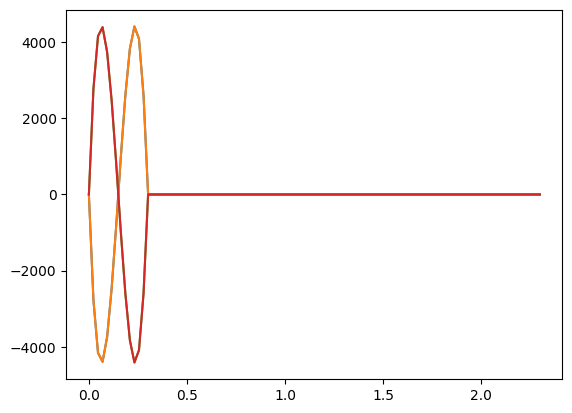

In [157]:
plt.plot(times,[evaluate_quintic(coeffs_theta1_go,time,trajectory_time)[2] for time in times])
plt.plot(times,[evaluate_quintic(coeffs_theta2_go,time,trajectory_time)[2] for time in times])
plt.plot(times,[evaluate_quintic(coeffs_theta1_back,time,trajectory_time)[2] for time in times])
plt.plot(times,[evaluate_quintic(coeffs_theta2_back,time,trajectory_time)[2] for time in times])

In [ ]:
robot.set_control_mode("torque")

t_0=time.time()

loops=1
completed=0

robot_times=[]
robot_theta1=[]
robot_theta2=[]

robot_omega1=[]
robot_omega2=[]

while completed<loops:
    actual_time=time.time()-t_0
    
    if actual_time<trajectory_time:
        objective_angle_theta1=evaluate_quintic(coeffs_theta1_go,actual_time,trajectory_time)[0]
        objective_angle_theta2=evaluate_quintic(coeffs_theta2_go,actual_time,trajectory_time)[0]
        
        objective_speed_theta1=evaluate_quintic(coeffs_theta1_go,actual_time,trajectory_time)[1]
        objective_speed_theta2=evaluate_quintic(coeffs_theta2_go,actual_time,trajectory_time)[1]
    elif actual_time<(trajectory_time+1):
        objective_angle_theta1=evaluate_quintic(coeffs_theta1_go,trajectory_time,trajectory_time)[0]
        objective_angle_theta2=evaluate_quintic(coeffs_theta2_go,trajectory_time,trajectory_time)[0]
        
        objective_speed_theta1=evaluate_quintic(coeffs_theta1_go,trajectory_time,trajectory_time)[1]
        objective_speed_theta2=evaluate_quintic(coeffs_theta2_go,trajectory_time,trajectory_time)[1]
    elif actual_time<(trajectory_time*2+1):
        objective_angle_theta1=evaluate_quintic(coeffs_theta1_back,actual_time-(trajectory_time+1),trajectory_time)[0]
        objective_angle_theta2=evaluate_quintic(coeffs_theta2_back,actual_time-(trajectory_time+1),trajectory_time)[0]
        
        objective_speed_theta1=evaluate_quintic(coeffs_theta1_back,actual_time-(trajectory_time+1),trajectory_time)[1]
        objective_speed_theta2=evaluate_quintic(coeffs_theta2_back,actual_time-(trajectory_time+1),trajectory_time)[1]
    elif actual_time<(trajectory_time*2+1*2):
        objective_angle_theta1=evaluate_quintic(coeffs_theta1_back,trajectory_time,trajectory_time)[0]
        objective_angle_theta2=evaluate_quintic(coeffs_theta2_back,trajectory_time,trajectory_time)[0]
        
        objective_speed_theta1=evaluate_quintic(coeffs_theta1_back,trajectory_time,trajectory_time)[1]
        objective_speed_theta2=evaluate_quintic(coeffs_theta2_back,trajectory_time,trajectory_time)[1]
    else:
        t_0=time.time()
        completed+=1
    
    data=robot.get_motors_data()
    
    actual_theta1=data["angle"][0]
    actual_theta2=data["angle"][1]
    
    actual_speed1=data["speed"][0]
    actual_speed2=data["speed"][1]
    
    robot_times.append(actual_time)
    robot_theta1.append(actual_theta1)
    robot_theta2.append(actual_theta2)
    robot_omega1.append(actual_speed1)
    robot_omega2.append(actual_speed2)
    
    target1=0.01*(objective_angle_theta1-actual_theta1)+0.005*(objective_speed_theta1-actual_speed1)
    target2=0.01*(objective_angle_theta2-actual_theta2)+0.005*(objective_speed_theta2-actual_speed2)
    
    robot.set_target(target1,target2)
    
    time.sleep(0.01)

Control Mode set to 'torque'. Setting targets to [0, 0]



In [150]:
robot.reactivate()
robot.set_control_mode("position",theta1_pick,theta2_pick)

Control Mode set to 'position'. Setting targets to [177.97408142381062, -108.94326081883368]



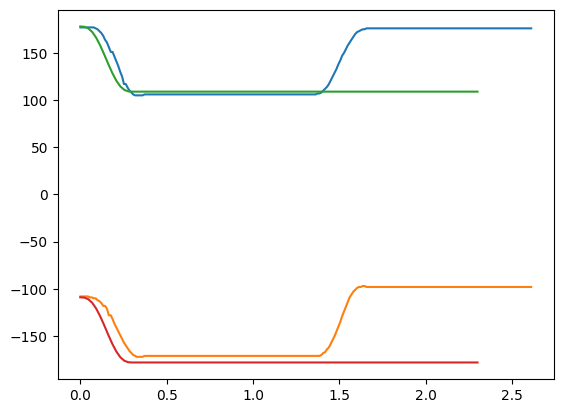

In [158]:
plt.plot(robot_times,robot_theta1)
plt.plot(robot_times,robot_theta2)

plt.plot(times,[evaluate_quintic(coeffs_theta1_go,time,trajectory_time)[0] for time in times])
plt.plot(times,[evaluate_quintic(coeffs_theta2_go,time,trajectory_time)[0] for time in times])

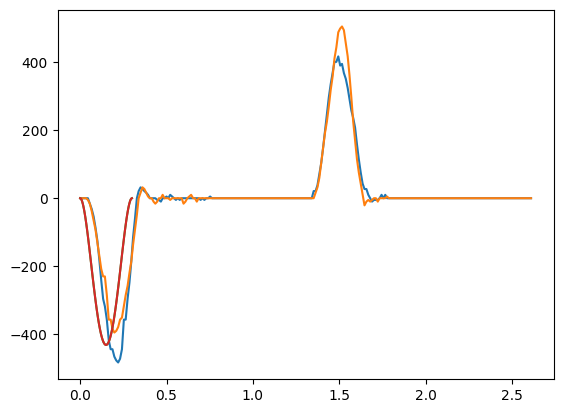

In [154]:
plt.plot(robot_times,robot_omega1)
plt.plot(robot_times,robot_omega2)

plt.plot(times,[evaluate_quintic(coeffs_theta1_go,time,trajectory_time)[1] for time in times])
plt.plot(times,[evaluate_quintic(coeffs_theta2_go,time,trajectory_time)[1] for time in times])
